# Module 2: Epidemic Modeling of a Mystery Virus

## Team Members:
Zain Abed and Grace Lee

## Project Title:
Mystery Virus Epidemic Modeling

## Project Goal:
This project aims to model and examine the disease spread and outbreak of a "mystery virus", comparing predicted disease models to  real disease spread.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*

In [1]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
From Data Release #1, because the data was taken from early on into the infection, exponential growth was assumed. To estimate R0, `curve_fit` was used to make an exponential growth curve fitted to the plotted data points. Assuming growth was exponential, R0 was calculated using R0 = e^(r*D), producing an R0 of 1.27.

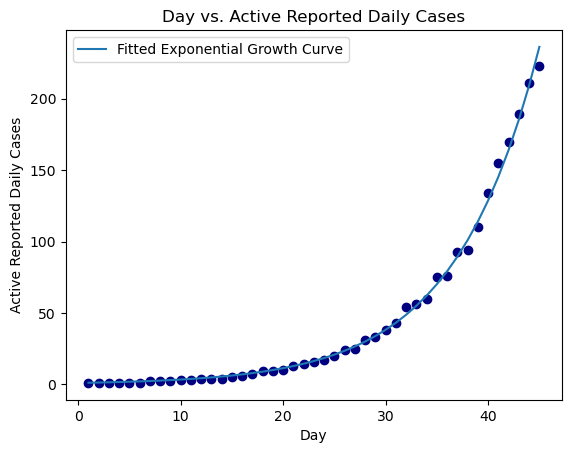

Estimated R0: 1.2749328499223294


In [2]:
#Importing Data Release #1
data = pd.read_csv("/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#Define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

#Fitting exponential growth model to the data.
x = data["day"]
y = data["active reported daily cases"]

param, covariance = curve_fit(exponential_growth, x, y)

# Plotting our data
plt.scatter(data["day"], data["active reported daily cases"], color = 'navy')
plt.plot(x, exponential_growth(x, *param), label='Fitted Exponential Growth Curve')
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("Day vs. Active Reported Daily Cases")
plt.legend()
plt.show()

# Approximate R0 using this fit
r0 = np.exp(param[0] * 2) # The infectious period is 2 days. Use e^(r * D) to estimate R0
print ("Estimated R0:", r0)

### Similar Viruses and Accuracy
The first closest virus is Seasonal Influenza, with an R0 of 1.3. It's highly contagiuous and causes fever coughing, fever, and fatigue. The best way to avoid it is by getting yearly immunizations. Another virus with a similar R0 value is the H1N1 variant of Influenza. It has very similar symptoms and is also easily preventable with an annual vaccine. 

I believe our R0 estimate to be pretty good but slightly off. It's clear that the vaccine is growing but it takes a while before you see the true exponential growth. I also believe it to be slightly off based on conversations with peers and their estimated values. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [3]:
# Generative AI tools were used in assistance of writing some portions of code and identifying bugs when they occured

data2 = pd.read_csv('/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#2.csv')

# Total population size
N = 17900

#Creating an array to hold the timepoints (days)
timepoints = data2["day"]


#Initial conditions for the SEIR model
S0 = 17899
E0 = 1
I0 = 1
R0 = 0

#Function that finds the predicted number of susceptible, exposed, infectious, and recovered individuals at each timepoint based on the SEIR model equations and the input parameters
def SEIR_model(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
   #Initializing SEIR model parameters and lists to store values
    S = [S0]
    E = [E0]
    I = [I0]
    R = [R0]

    for t in timepoints:
        dS = -beta/N * I[t-1] * S[t-1]
        dE = beta/N * I[t-1] * S[t-1] - (sigma * E[t-1])
        dI = sigma * E[t-1] - (gamma * I[t-1])
        dR = gamma * I[t-1]

        S.append(S[t-1]+dS)
        E.append(E[t-1]+dE)
        I.append(I[t-1]+dI)
        R.append(R[t-1]+dR)
    return (np.array(S), np.array(E), np.array(I), np.array(R))

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [8]:
def optimize(timepoints, N, S0, E0, I0, R0, data2):
    # Define the predicted ranges for beta, sigma, and gamma
    beta = np.arange(.2, 1.5, .01) #Wide range of values for beta to test, as the contagiousness is unknown
    sigma = np.arange(.4, .6, .005) #narrower range of sigma values, as we know the latent period is ~2 days, so sigma should be around 0.5 (1/2)
    gamma = np.arange(1/11, 1/7, .001) #narrower range of gamma values, as we know the infectious period (pre-symptomatic infectious period + symptoma duration) is between 7 and 11 days, so gamma should be between 1/11 and 1/7
    
    beta_index = []
    sigma_index = []
    gamma_index = []

    SSE = []
    infections = data2["active reported daily cases"]

    for b in beta:
        for s in sigma:
            for g in gamma:
                predicted = SEIR_model(b, s, g, S0, E0, I0, R0, timepoints, N)
                n = len(infections)
                I = predicted[2][1:n+1] #Extracting the predicted number of infectious individuals at each timepoint from the SEIR model output
                sse_calc = np.sum((I-infections)**2)
                SSE.append(sse_calc)
                beta_index.append(b)
                sigma_index.append(s)
                gamma_index.append(g)

    best_idx   = np.argmin(SSE)
    best_beta  = beta_index[best_idx]
    best_sigma = sigma_index[best_idx]
    best_gamma = gamma_index[best_idx]
    best_sse   = SSE[best_idx]

    return best_beta, best_sigma, best_gamma, best_sse



best_beta, best_sigma, best_gamma, best_sse = optimize(timepoints, N, S0, E0, I0, R0, data2)

print(f"Best beta: ",  best_beta)
print(f"Best sigma: ", best_sigma)
print(f"Best gamma: ", best_gamma)
print(f"Best SSE: ",   best_sse)

Best beta:  0.3300000000000001
Best sigma:  0.5350000000000001
Best gamma:  0.14190909090909096
Best SSE:  74689.87651924638


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

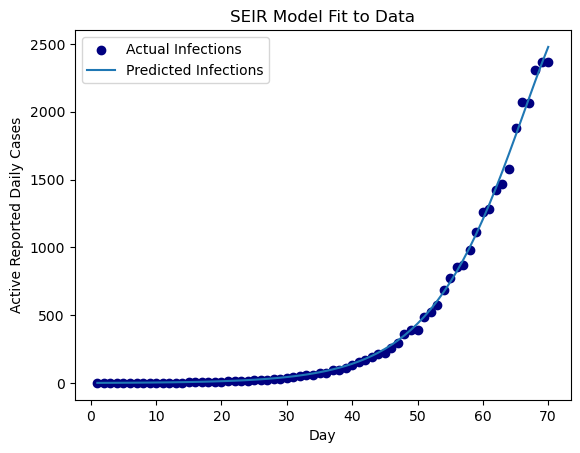

In [5]:
plt.scatter(timepoints, data2["active reported daily cases"], label="Actual Infections", color = 'navy')
predicted = SEIR_model(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N)
plt.plot(timepoints, predicted[2][1:len(timepoints)+1], label="Predicted Infections")
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Peak day: 78
Peak active cases: 3015.634292573587


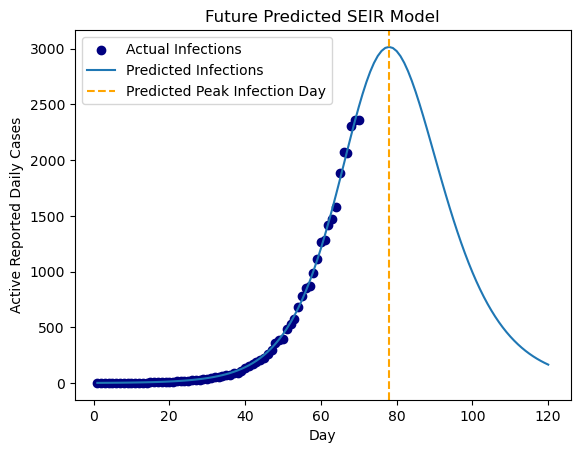

In [6]:
future_timepoints = np.arange(1,121)
future_predicted = SEIR_model(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, future_timepoints, N)
plt.scatter(timepoints, data2["active reported daily cases"], label="Actual Infections", color = 'navy')
plt.plot(future_timepoints, future_predicted[2][1:len(future_timepoints)+1], label="Predicted Infections")
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("Future Predicted SEIR Model")


# Pull predicted infected values
predicted_I = future_predicted[2][1:len(future_timepoints)+1]

# Find peak infections
peak_cases = np.max(predicted_I)

# Find index of peak
peak_index = np.argmax(predicted_I)

# Corresponding day
peak_day = future_timepoints[peak_index]

print("Peak day:", peak_day)
print("Peak active cases:", peak_cases)

plt.axvline(x=peak_day, color='orange', linestyle='--', label='Predicted Peak Infection Day')
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


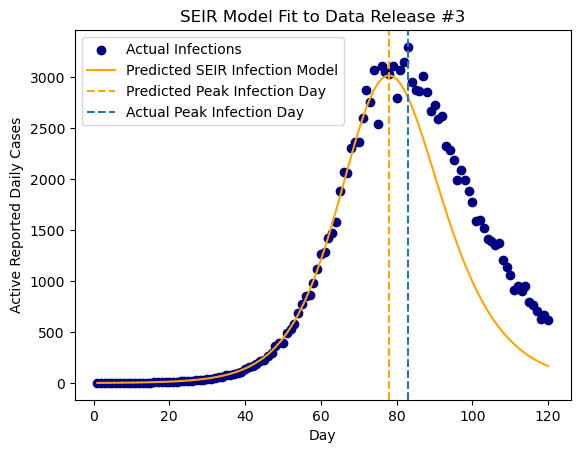

In [18]:
data3 = pd.read_csv('/Users/gracelee/Documents/computational BME/Module-2-Epidemics-SIR-Modeling_lee_abed/Data/mystery_virus_daily_active_counts_RELEASE#3.csv')
timepoints3 = data3["day"]

plt.scatter(data3["day"], data3["active reported daily cases"], label="Actual Infections", color = 'navy')

plt.plot(future_timepoints, future_predicted[2][1:len(future_timepoints)+1], label="Predicted SEIR Infection Model", color = 'orange')
plt.axvline(x=peak_day, color='orange', linestyle='--', label='Predicted Peak Infection Day')
plt.axvline(x=83, linestyle='--', label='Actual Peak Infection Day')
plt.xlabel("Day")
plt.ylabel("Active Reported Daily Cases")
plt.title("SEIR Model Fit to Data Release #3")
plt.legend()
plt.show()

### Error in our Estimate

Relative error is calculated by $$\frac{|Actual Value - Measured|}{Actual Value} \times 100\%$$

The code estimated cases to peak at day 78, with 3015 cases. Referring to Data Release #3, the true peak was at day 83, with 3294 cases. Using this information, the relative error in y and x of the predicted SEIR model was calculated using Desmos.

Error in peak number of cases (error in y): **8.451%**

Error in day of peak case number (error in x): **6.024%**

The calculated SSE of 74,690 shows a large deviance between the predicted values and actual data values. Error could be introduced from using Euler's method to estimate S, E, I, and R values. Over iterations, numerical errors in these estimates compound and cause the SEIR model to diverge from the actual data. Additionally, beta, sigma, and gamma values may not remain constant the entire time. Transmission rates may increase or decrease as people start masking up, or take other actions to reduce their exposure to the outbreak. However, the SEIR model assumes beta, sigma, and gamma are constant, which is an oversimplification of real disease spread that can create the error seen between the predicted and true values.

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*